In [ ]:
!pip install qiskit
!pip install qiskit-ibm-runtime
!pip install qiskit_aer
!pip install qiskit[visualization]
!pip install pylatexenc
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from math import pi, sqrt
from qiskit.visualization import plot_bloch_multivector, plot_histogram

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, Pauli, partial_trace, Statevector
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()
    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])
    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]
    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]
    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

def visualize_pauli_x():
    gate_name = "x"
    qc = QuantumCircuit(1)
    qc.x(0)
    qc.draw('mpl')

    print(f"\nTruth Table for {gate_name.upper()} Gate:")
    rows = []
    input_states = [(b,) for b in [0, 1]]
    for state_in in input_states:
        test_qc = QuantumCircuit(1)
        if state_in[0] == 1:
            test_qc.x(0)
        test_qc.x(0)
        state = Statevector.from_instruction(test_qc)
        amp_dict = {f"|{format(i, '01b')}⟩": amp for i, amp in enumerate(state.data)}
        row = [f"|{state_in[0]}⟩"] + [amp_dict.get(f"|{b:01b}⟩", 0) for b in range(2)]
        rows.append(row)
    df = pd.DataFrame(rows, columns=["Input State", "|0⟩", "|1⟩"])
    display(df)

    # Bloch sphere for |0⟩ and |1⟩
    for base in [0, 1]:
        qc = QuantumCircuit(1)
        if base == 1:
            qc.x(0)
        qc.x(0)
        label = f"X on |{base}⟩"
        show_bloch_state(qc, label=label, base=base)

visualize_pauli_x()

## Pauli X Gate


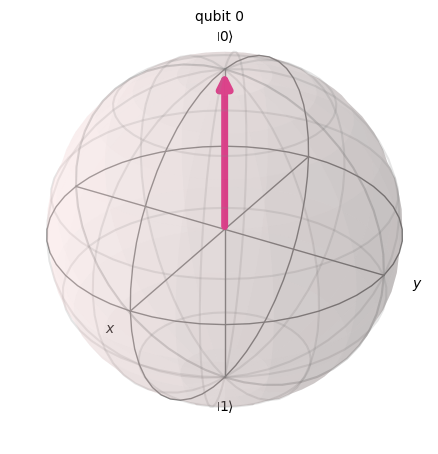

In [ ]:
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(1)
state = Statevector.from_instruction(qc)
plot_bloch_multivector(state)

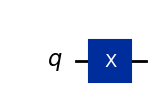

In [ ]:
qc = QuantumCircuit(1)
qc.x(0)
qc.draw('mpl')

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


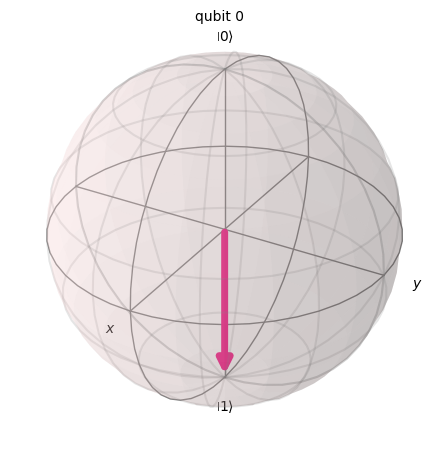

In [ ]:
state = Statevector.from_instruction(qc)
print(state)
plot_bloch_multivector(state)

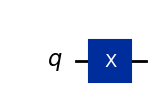

,Input State,|0⟩,|1⟩
0,|0⟩,0.0+0.0j,1.0+0.0j
1,|1⟩,1.0+0.0j,0.0+0.0j


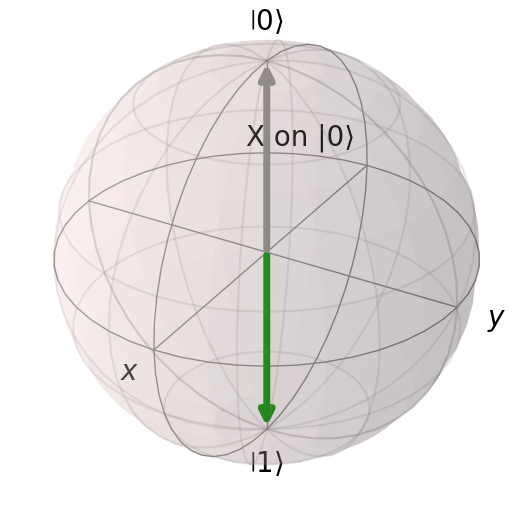

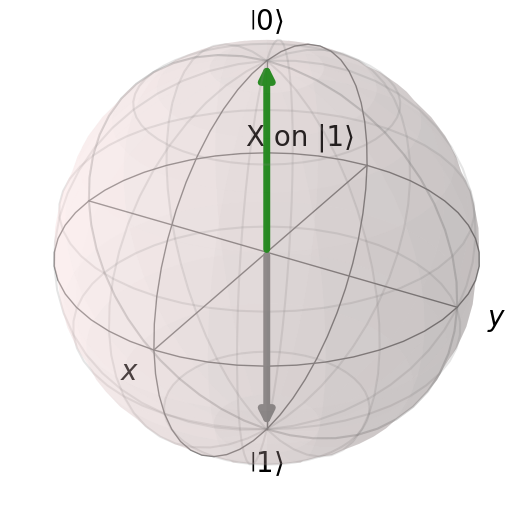

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, Pauli, partial_trace, Statevector
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, base=0, label="Gate"):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()
    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != 0])
    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]
    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]
    bloch = Bloch()
    bloch.vector_color = ['gray', 'green']
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.add_annotation([0.4, 0.4, 0.9], f"{label} on |{base}⟩")
    bloch.show()

# -------- X Gate --------

qc = QuantumCircuit(1)
qc.x(0)
display(qc.draw('mpl'))

rows = []
# Input |0>
test_qc = QuantumCircuit(1)
test_qc.x(0)
state = Statevector.from_instruction(test_qc)
amp_dict = {f"|{format(i, '01b')}⟩": amp for i, amp in enumerate(state.data)}
rows.append(["|0⟩"] + [amp_dict.get(f"|{b:01b}⟩", 0) for b in [0, 1]])
# Input |1>
test_qc = QuantumCircuit(1)
test_qc.x(0)
test_qc.x(0)
state = Statevector.from_instruction(test_qc)
amp_dict = {f"|{format(i, '01b')}⟩": amp for i, amp in enumerate(state.data)}
rows.append(["|1⟩"] + [amp_dict.get(f"|{b:01b}⟩", 0) for b in [0, 1]])

df_x = pd.DataFrame(rows, columns=["Input State", "|0⟩", "|1⟩"])
display(df_x)

# Bloch sphere before and after for |0>
qc0 = QuantumCircuit(1)
qc0.x(0)
show_bloch_state(qc0, base=0, label="X")

# Bloch sphere before and after for |1>
qc1 = QuantumCircuit(1)
qc1.x(0)
qc1.x(0)
show_bloch_state(qc1, base=1, label="X")


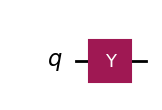

,Input State,|0⟩,|1⟩
0,|0⟩,0.0+0.0j,0.0+1.0j
1,|1⟩,0.0-1.0j,0.0+0.0j


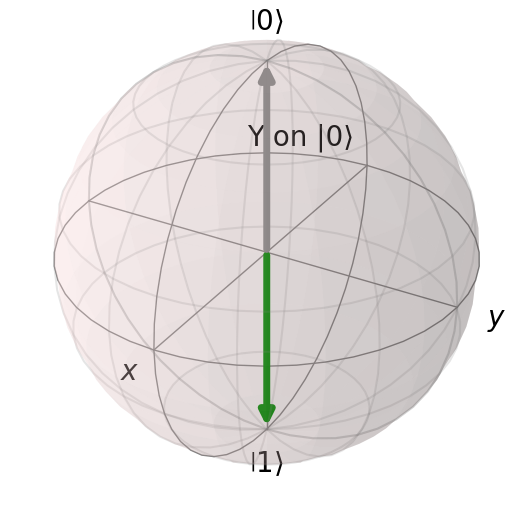

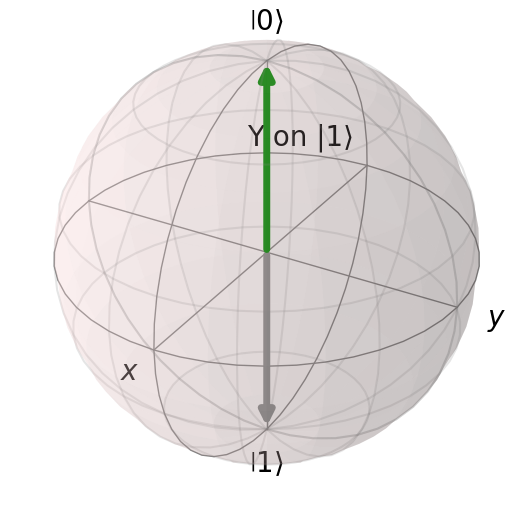

In [ ]:
# -------- Y Gate --------

qc = QuantumCircuit(1)
qc.y(0)
display(qc.draw('mpl'))

rows = []
# Input |0>
test_qc = QuantumCircuit(1)
test_qc.y(0)
state = Statevector.from_instruction(test_qc)
amp_dict = {f"|{format(i, '01b')}⟩": amp for i, amp in enumerate(state.data)}
rows.append(["|0⟩"] + [amp_dict.get(f"|{b:01b}⟩", 0) for b in [0, 1]])
# Input |1>
test_qc = QuantumCircuit(1)
test_qc.x(0)  # prepare |1>
test_qc.y(0)
state = Statevector.from_instruction(test_qc)
amp_dict = {f"|{format(i, '01b')}⟩": amp for i, amp in enumerate(state.data)}
rows.append(["|1⟩"] + [amp_dict.get(f"|{b:01b}⟩", 0) for b in [0, 1]])

df_y = pd.DataFrame(rows, columns=["Input State", "|0⟩", "|1⟩"])
display(df_y)

# Bloch sphere before and after for |0>
qc0 = QuantumCircuit(1)
qc0.y(0)
show_bloch_state(qc0, base=0, label="Y")

# Bloch sphere before and after for |1>
qc1 = QuantumCircuit(1)
qc1.x(0)  # prepare |1>
qc1.y(0)
show_bloch_state(qc1, base=1, label="Y")


Pauli-Z Circuit:


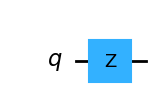

Truth Table for Z gate:


,Input,|0⟩,|1⟩
0,|0⟩,1.0+0.0j,0.0+0.0j
1,|1⟩,0.0+0.0j,-1.0+0.0j


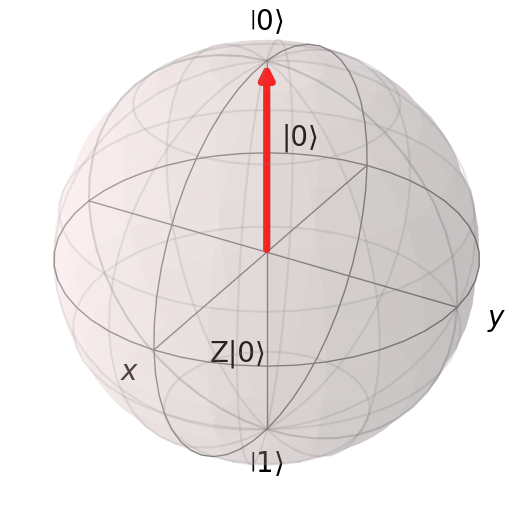

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, Pauli, partial_trace, Statevector
from qiskit.visualization.bloch import Bloch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

simulator = AerSimulator()

def bloch_before_after(circuit_before, circuit_after, qubit=0, label_before="Before", label_after="After"):
    """Plot before and after states on the same Bloch sphere"""
    # Get before vector
    cb = circuit_before.copy()
    cb.save_statevector()
    resb = simulator.run(transpile(cb, simulator)).result()
    sv_b = resb.get_statevector()
    rho_b = DensityMatrix(sv_b)
    reduced_b = partial_trace(rho_b, [i for i in range(cb.num_qubits) if i != qubit])
    vec_b = [
        np.real(reduced_b.expectation_value(Pauli("X"))),
        np.real(reduced_b.expectation_value(Pauli("Y"))),
        np.real(reduced_b.expectation_value(Pauli("Z")))
    ]

    # Get after vector
    ca = circuit_after.copy()
    ca.save_statevector()
    resa = simulator.run(transpile(ca, simulator)).result()
    sv_a = resa.get_statevector()
    rho_a = DensityMatrix(sv_a)
    reduced_a = partial_trace(rho_a, [i for i in range(ca.num_qubits) if i != qubit])
    vec_a = [
        np.real(reduced_a.expectation_value(Pauli("X"))),
        np.real(reduced_a.expectation_value(Pauli("Y"))),
        np.real(reduced_a.expectation_value(Pauli("Z")))
    ]

    # Draw Bloch sphere
    bloch = Bloch()
    bloch.add_vectors(vec_b)
    bloch.add_vectors(vec_a)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label_before)
    bloch.add_annotation([-0.4, -0.4, -0.9], label_after)
    bloch.show()

def truth_table_single_qubit(gate_fn):
    rows = []
    for b in [0, 1]:
        qc = QuantumCircuit(1)
        if b == 1:
            qc.x(0)
        gate_fn(qc)
        state = Statevector.from_instruction(qc)
        amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}
        rows.append([f"|{b}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])
    df = pd.DataFrame(rows, columns=["Input", "|0⟩", "|1⟩"])
    display(df)

# ----- Pauli-Z -----
qc_before = QuantumCircuit(1)
qc_after = QuantumCircuit(1)
qc_after.z(0)

# Circuit diagram
print("Pauli-Z Circuit:")
display(qc_after.draw('mpl'))

# Truth table
print("Truth Table for Z gate:")
truth_table_single_qubit(lambda qc: qc.z(0))

# Bloch sphere before/after
bloch_before_after(qc_before, qc_after, label_before="|0⟩", label_after="Z|0⟩")


Pauli-Z Circuit (starting from |+>):


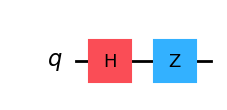

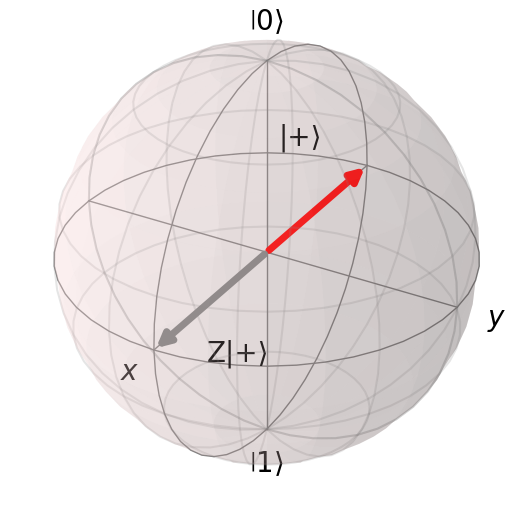

In [ ]:
# ----- Pauli-Z: visualizing with |+> as input -----
qc_before = QuantumCircuit(1)
qc_before.h(0)  # Prepare |+> state

qc_after = QuantumCircuit(1)
qc_after.h(0)   # Prepare |+>
qc_after.z(0)   # Apply Z gate

# Circuit diagram
print("Pauli-Z Circuit (starting from |+>):")
display(qc_after.draw('mpl'))

# Bloch sphere for |+> -> Z|+>
bloch_before_after(qc_before, qc_after, label_before="|+⟩", label_after="Z|+⟩")


,Input State,|0⟩,|1⟩
0,|0⟩,0.0+0.0j,1.0+0.0j
1,|1⟩,1.0+0.0j,0.0+0.0j


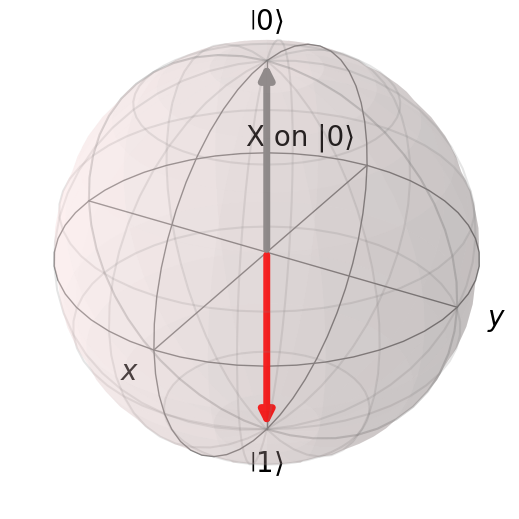

,Input State,|0⟩,|1⟩
0,|0⟩,0.0+0.0j,1.0+0.0j
1,|1⟩,1.0+0.0j,0.0+0.0j


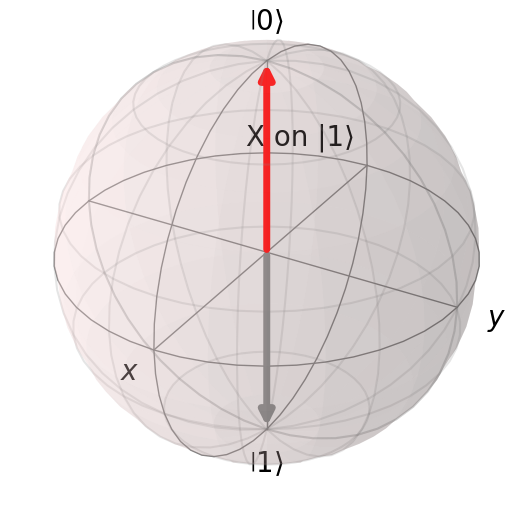

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, Pauli, partial_trace, Statevector
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)  # Initial
    bloch.add_vectors(current_vector)  # Final
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

def visualize_x_gate(base=0):
    qc = QuantumCircuit(1)
    if base == 1:
        qc.x(0)  # Prepare |1>
    qc.x(0)  # Apply Pauli-X gate

    qc.draw('mpl')

    # Truth table
    rows = []
    for bit in [0, 1]:
        test_qc = QuantumCircuit(1)
        if bit:
            test_qc.x(0)
        test_qc.x(0)  # Apply X
        state = Statevector.from_instruction(test_qc)
        amp_dict = {
            f"|{i:01b}⟩": amp for i, amp in enumerate(state.data)
        }
        row = [f"|{bit}⟩"] + [amp_dict.get(f"|{b:01b}⟩", 0) for b in range(2)]
        rows.append(row)

    df = pd.DataFrame(rows, columns=["Input State", "|0⟩", "|1⟩"])
    display(df)

    # Bloch sphere visualization
    show_bloch_state(qc, label="X on |0⟩" if base == 0 else "X on |1⟩", base=base)

# Example usage
visualize_x_gate(base=0)  # Start from |0>
visualize_x_gate(base=1)  # Start from |1>


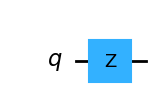

,Input State,|0⟩,|1⟩
0,|0⟩,1.0+0.0j,0.0+0.0j
1,|1⟩,0.0+0.0j,-1.0+0.0j


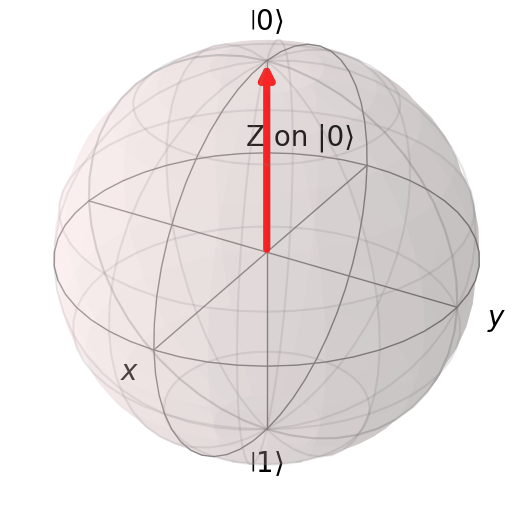

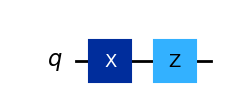

,Input State,|0⟩,|1⟩
0,|0⟩,1.0+0.0j,0.0+0.0j
1,|1⟩,0.0+0.0j,-1.0+0.0j


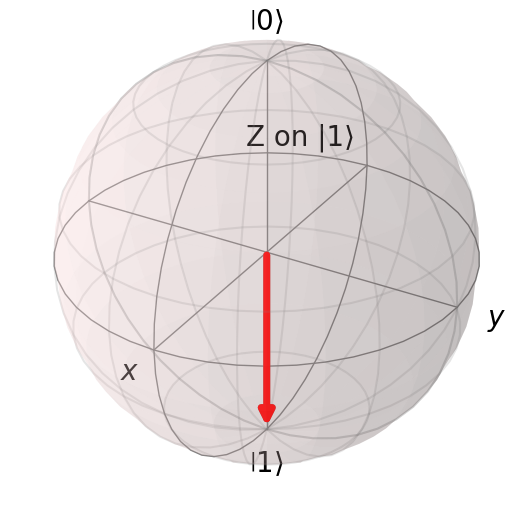

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, Pauli, partial_trace, Statevector
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

def visualize_pauli_z(base=0):
    # Build circuit
    qc = QuantumCircuit(1)
    if base == 1:
        qc.x(0)
    qc.z(0)

    # Show circuit diagram
    display(qc.draw('mpl'))

    # Truth table
    rows = []
    for b in [0, 1]:
        test_qc = QuantumCircuit(1)
        if b == 1:
            test_qc.x(0)
        test_qc.z(0)
        state = Statevector.from_instruction(test_qc)
        amp_dict = {f"|{i:01b}⟩": amp for i, amp in enumerate(state.data)}
        row = [f"|{b}⟩"] + [amp_dict.get(f"|{i:01b}⟩", 0) for i in range(2)]
        rows.append(row)

    df = pd.DataFrame(rows, columns=["Input State", "|0⟩", "|1⟩"])
    display(df)

    # Bloch sphere
    label = f"Z on |{base}⟩"
    show_bloch_state(qc, label=label, base=base)

# Run for |0⟩
visualize_pauli_z(base=0)

# Run for |1⟩
visualize_pauli_z(base=1)


Hadamard Gate Circuit:


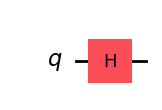


Truth Table for H Gate:


,Input State,|0⟩ amplitude,|1⟩ amplitude
0,|0⟩,0.707107+0.000000j,0.707107+0.000000j
1,|1⟩,0.707107+0.000000j,-0.707107+0.000000j


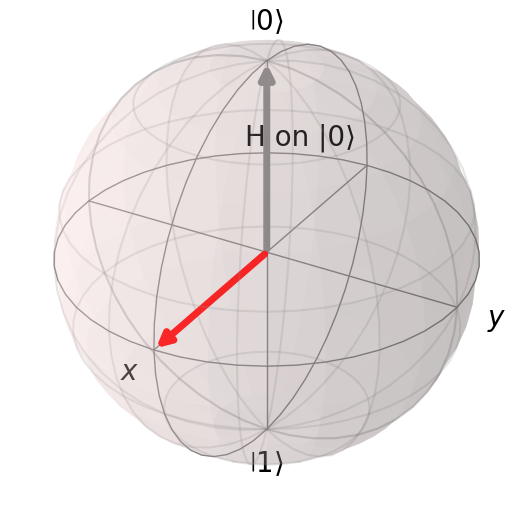

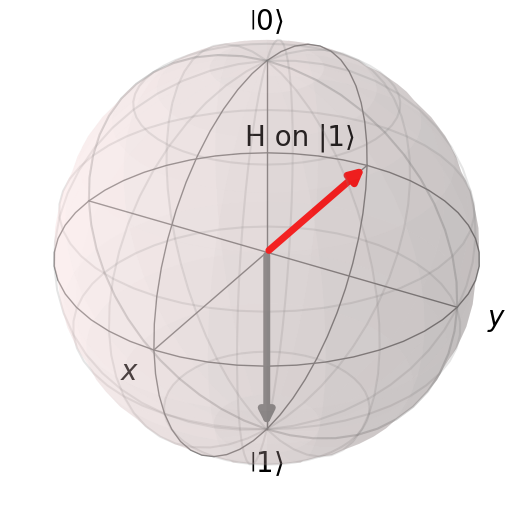

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulator
simulator = AerSimulator()

# Function to display Bloch Sphere state
def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

# --------------------------
# 1️⃣ Create Hadamard circuit
# --------------------------
qc = QuantumCircuit(1)
qc.h(0)

# Show circuit diagram
print("Hadamard Gate Circuit:")
display(qc.draw("mpl"))   # <-- This will show the gate visually in Jupyter

# --------------------------
# 2️⃣ Generate truth table
# --------------------------
rows = []
for state_in in [0, 1]:
    test_qc = QuantumCircuit(1)
    if state_in == 1:
        test_qc.x(0)
    test_qc.h(0)

    state = Statevector.from_instruction(test_qc)
    amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}

    rows.append([f"|{state_in}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])

df = pd.DataFrame(rows, columns=["Input State", "|0⟩ amplitude", "|1⟩ amplitude"])
print("\nTruth Table for H Gate:")
display(df)

# --------------------------
# 3️⃣ Bloch sphere views
# --------------------------
show_bloch_state(qc, label="H on |0⟩", base=0)

qc_1 = QuantumCircuit(1)
qc_1.x(0)
qc_1.h(0)
show_bloch_state(qc_1, label="H on |1⟩", base=1)


S Gate Circuit:


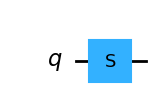


Truth Table for S Gate:


,Input State,|0⟩ amplitude,|1⟩ amplitude
0,|0⟩,1.0+0.0j,0.0+0.0j
1,|1⟩,0.0+0.0j,0.0+1.0j


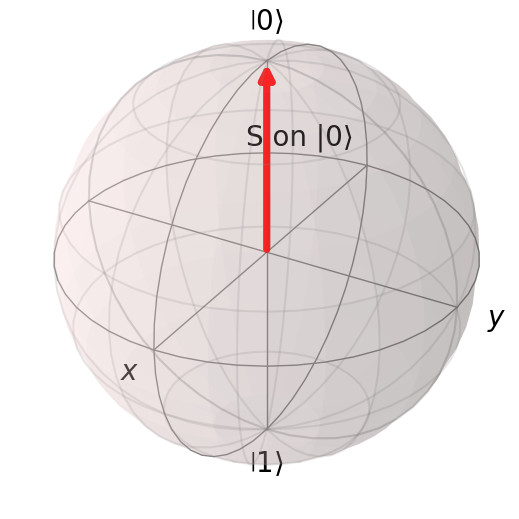

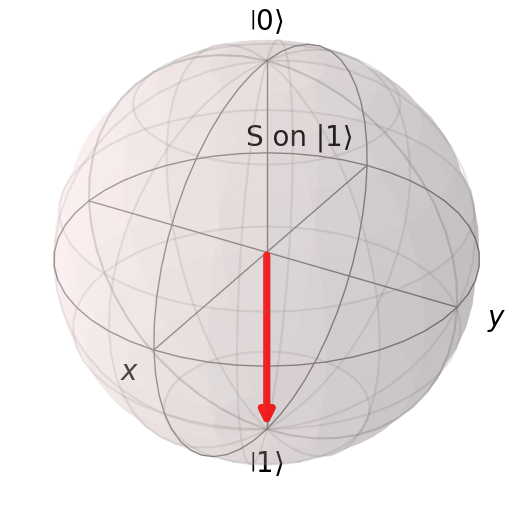

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

# Simulator
simulator = AerSimulator()

# Function to display Bloch Sphere state
def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

# --------------------------
# 1️⃣ Create S gate circuit
# --------------------------
qc = QuantumCircuit(1)
qc.s(0)

# Show circuit diagram
print("S Gate Circuit:")
display(qc.draw("mpl"))

# --------------------------
# 2️⃣ Generate truth table
# --------------------------
rows = []
for state_in in [0, 1]:
    test_qc = QuantumCircuit(1)
    if state_in == 1:
        test_qc.x(0)
    test_qc.s(0)

    state = Statevector.from_instruction(test_qc)
    amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}

    rows.append([f"|{state_in}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])

df = pd.DataFrame(rows, columns=["Input State", "|0⟩ amplitude", "|1⟩ amplitude"])
print("\nTruth Table for S Gate:")
display(df)

# --------------------------
# 3️⃣ Bloch sphere views
# --------------------------
show_bloch_state(qc, label="S on |0⟩", base=0)

qc_1 = QuantumCircuit(1)
qc_1.x(0)
qc_1.s(0)
show_bloch_state(qc_1, label="S on |1⟩", base=1)


T Gate Circuit:


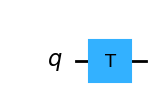


Truth Table for T Gate:


,Input State,|0⟩ amplitude,|1⟩ amplitude
0,|0⟩,1.0+0.0j,0.000000+0.000000j
1,|1⟩,0.0+0.0j,0.707107+0.707107j


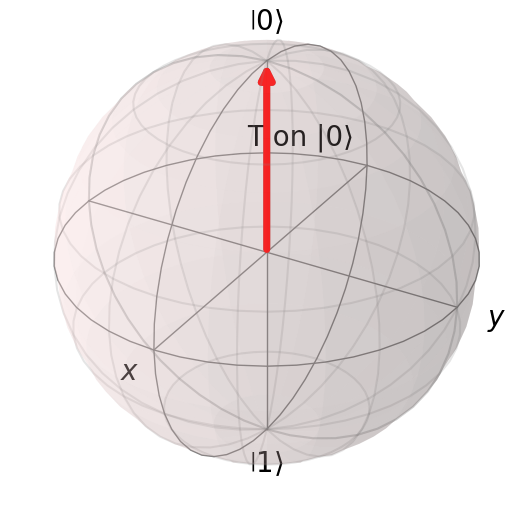

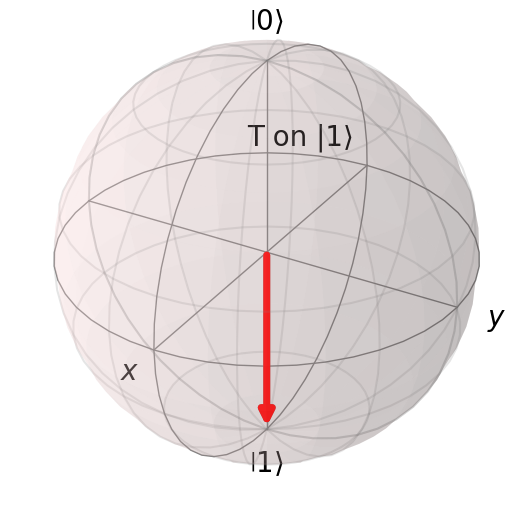

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

# Simulator
simulator = AerSimulator()

# Function to display Bloch Sphere state
def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

# --------------------------
# 1️⃣ Create T gate circuit
# --------------------------
qc = QuantumCircuit(1)
qc.t(0)

# Show circuit diagram
print("T Gate Circuit:")
display(qc.draw("mpl"))

# --------------------------
# 2️⃣ Generate truth table
# --------------------------
rows = []
for state_in in [0, 1]:
    test_qc = QuantumCircuit(1)
    if state_in == 1:
        test_qc.x(0)
    test_qc.t(0)

    state = Statevector.from_instruction(test_qc)
    amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}

    rows.append([f"|{state_in}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])

df = pd.DataFrame(rows, columns=["Input State", "|0⟩ amplitude", "|1⟩ amplitude"])
print("\nTruth Table for T Gate:")
display(df)

# --------------------------
# 3️⃣ Bloch sphere views
# --------------------------
show_bloch_state(qc, label="T on |0⟩", base=0)

qc_1 = QuantumCircuit(1)
qc_1.x(0)
qc_1.t(0)
show_bloch_state(qc_1, label="T on |1⟩", base=1)


RX(1.57) Gate Circuit:


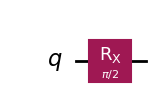


Truth Table for RX(1.57) Gate:


,Input State,|0⟩ amplitude,|1⟩ amplitude
0,|0⟩,0.707107+0.000000j,0.000000-0.707107j
1,|1⟩,0.000000-0.707107j,0.707107+0.000000j


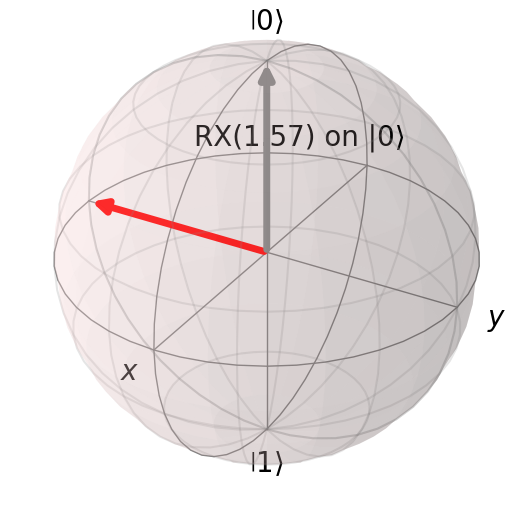

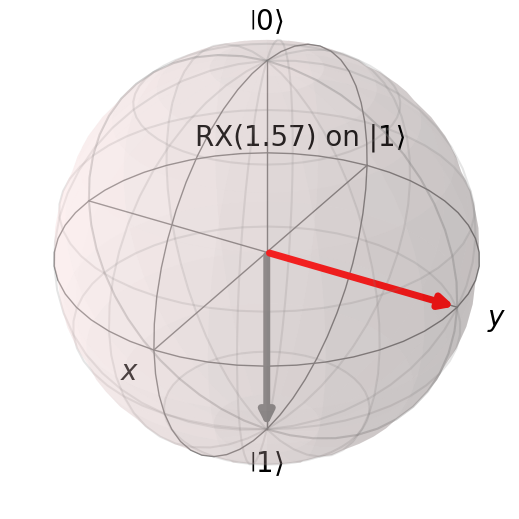

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

# Simulator
simulator = AerSimulator()

# Function to display Bloch Sphere state
def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

# --------------------------
# 1️⃣ Create RX(π/2) circuit
# --------------------------
theta = np.pi / 2
qc = QuantumCircuit(1)
qc.rx(theta, 0)

# Show circuit diagram
print(f"RX({theta:.2f}) Gate Circuit:")
display(qc.draw("mpl"))

# --------------------------
# 2️⃣ Generate truth table
# --------------------------
rows = []
for state_in in [0, 1]:
    test_qc = QuantumCircuit(1)
    if state_in == 1:
        test_qc.x(0)
    test_qc.rx(theta, 0)

    state = Statevector.from_instruction(test_qc)
    amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}

    rows.append([f"|{state_in}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])

df = pd.DataFrame(rows, columns=["Input State", "|0⟩ amplitude", "|1⟩ amplitude"])
print(f"\nTruth Table for RX({theta:.2f}) Gate:")
display(df)

# --------------------------
# 3️⃣ Bloch sphere views
# --------------------------
show_bloch_state(qc, label=f"RX({theta:.2f}) on |0⟩", base=0)

qc_1 = QuantumCircuit(1)
qc_1.x(0)
qc_1.rx(theta, 0)
show_bloch_state(qc_1, label=f"RX({theta:.2f}) on |1⟩", base=1)


RY(1.57) Gate Circuit:


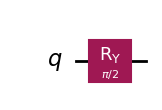


Truth Table for RY(1.57) Gate:


,Input State,|0⟩ amplitude,|1⟩ amplitude
0,|0⟩,0.707107+0.000000j,0.707107+0.000000j
1,|1⟩,-0.707107+0.000000j,0.707107+0.000000j


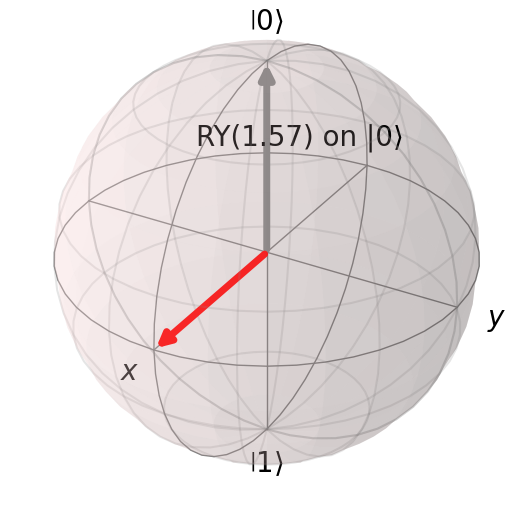

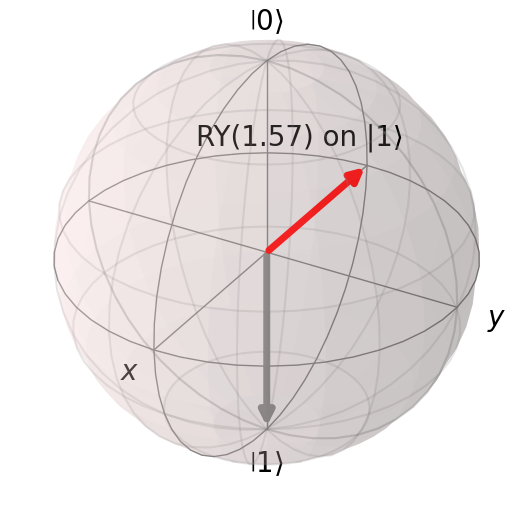

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

# Simulator
simulator = AerSimulator()

# Function to display Bloch Sphere state
def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

# --------------------------
# 1️⃣ Create RY(π/2) circuit
# --------------------------
theta = np.pi / 2
qc = QuantumCircuit(1)
qc.ry(theta, 0)

# Show circuit diagram
print(f"RY({theta:.2f}) Gate Circuit:")
display(qc.draw("mpl"))

# --------------------------
# 2️⃣ Generate truth table
# --------------------------
rows = []
for state_in in [0, 1]:
    test_qc = QuantumCircuit(1)
    if state_in == 1:
        test_qc.x(0)
    test_qc.ry(theta, 0)

    state = Statevector.from_instruction(test_qc)
    amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}

    rows.append([f"|{state_in}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])

df = pd.DataFrame(rows, columns=["Input State", "|0⟩ amplitude", "|1⟩ amplitude"])
print(f"\nTruth Table for RY({theta:.2f}) Gate:")
display(df)

# --------------------------
# 3️⃣ Bloch sphere views
# --------------------------
show_bloch_state(qc, label=f"RY({theta:.2f}) on |0⟩", base=0)

qc_1 = QuantumCircuit(1)
qc_1.x(0)
qc_1.ry(theta, 0)
show_bloch_state(qc_1, label=f"RY({theta:.2f}) on |1⟩", base=1)


RZ(1.57) Gate Circuit:


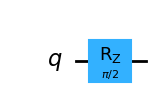


Truth Table for RZ(1.57) Gate:


,Input State,|0⟩ amplitude,|1⟩ amplitude
0,|0⟩,0.707107-0.707107j,0.000000+0.000000j
1,|1⟩,0.000000+0.000000j,0.707107+0.707107j


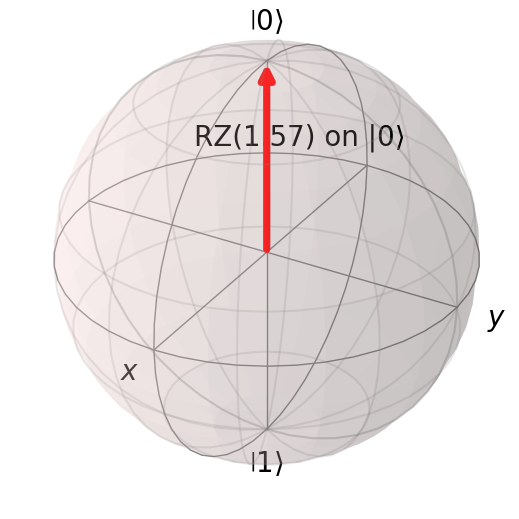

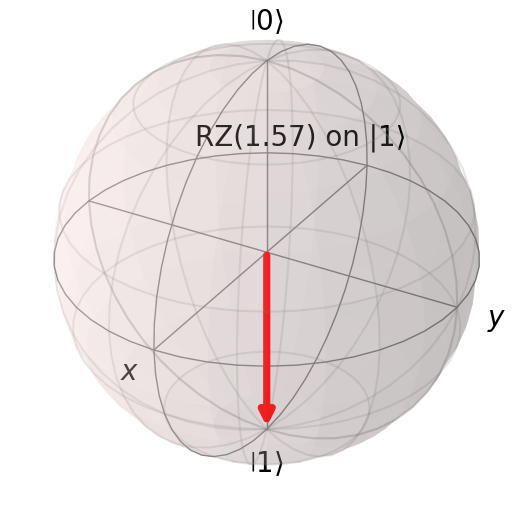

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

# Simulator
simulator = AerSimulator()

# Function to display Bloch Sphere state
def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

# --------------------------
# 1️⃣ Create RZ(π/2) circuit
# --------------------------
theta = np.pi / 2
qc = QuantumCircuit(1)
qc.rz(theta, 0)

# Show circuit diagram
print(f"RZ({theta:.2f}) Gate Circuit:")
display(qc.draw("mpl"))

# --------------------------
# 2️⃣ Generate truth table
# --------------------------
rows = []
for state_in in [0, 1]:
    test_qc = QuantumCircuit(1)
    if state_in == 1:
        test_qc.x(0)
    test_qc.rz(theta, 0)

    state = Statevector.from_instruction(test_qc)
    amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}

    rows.append([f"|{state_in}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])

df = pd.DataFrame(rows, columns=["Input State", "|0⟩ amplitude", "|1⟩ amplitude"])
print(f"\nTruth Table for RZ({theta:.2f}) Gate:")
display(df)

# --------------------------
# 3️⃣ Bloch sphere views
# --------------------------
show_bloch_state(qc, label=f"RZ({theta:.2f}) on |0⟩", base=0)

qc_1 = QuantumCircuit(1)
qc_1.x(0)
qc_1.rz(theta, 0)
show_bloch_state(qc_1, label=f"RZ({theta:.2f}) on |1⟩", base=1)


RZ(1.57) Gate Circuit:


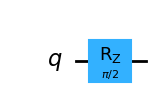


Truth Table for RZ(1.57) Gate:


,Input State,|0⟩ amplitude,|1⟩ amplitude
0,|0⟩,0.707107-0.707107j,0.000000+0.000000j
1,|1⟩,0.000000+0.000000j,0.707107+0.707107j


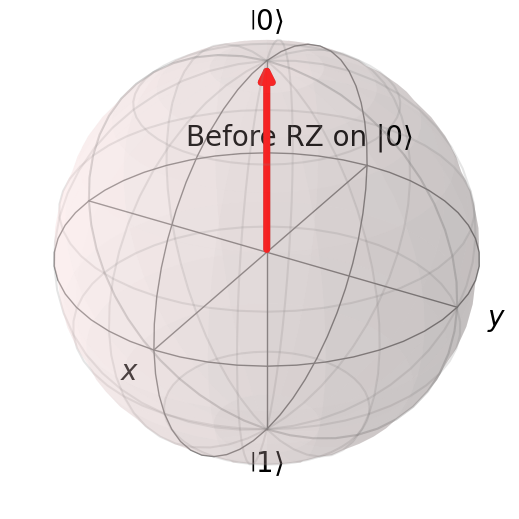

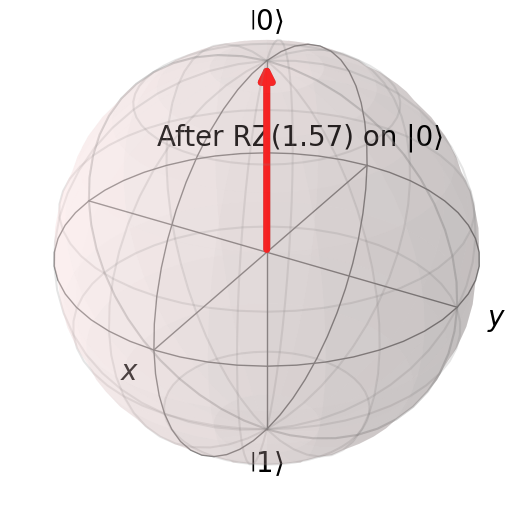

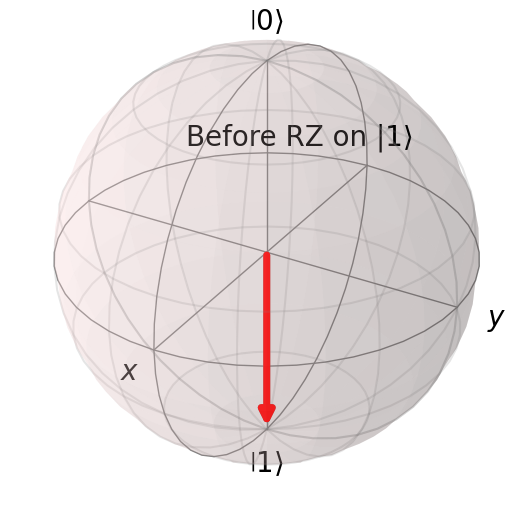

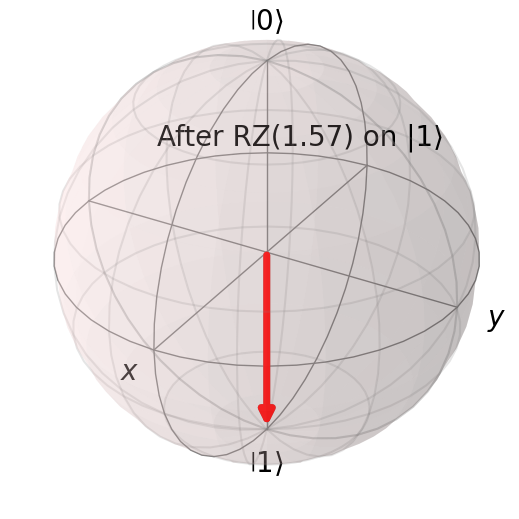

In [ ]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import numpy as np
import pandas as pd

# Simulator
simulator = AerSimulator()

# Function to display Bloch Sphere state
def show_bloch_state(circuit, qubit=0, label="State", base=0):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    base_vector = [0, 0, 1] if base == 0 else [0, 0, -1]

    bloch = Bloch()
    bloch.add_vectors(base_vector)
    bloch.add_vectors(current_vector)
    bloch.vector_color = ['gray', 'red']
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

# --------------------------
# Parameters
# --------------------------
theta = np.pi / 2

# --------------------------
# 1️⃣ Circuit diagram
# --------------------------
qc = QuantumCircuit(1)
qc.rz(theta, 0)
print(f"RZ({theta:.2f}) Gate Circuit:")
display(qc.draw("mpl"))

# --------------------------
# 2️⃣ Truth table
# --------------------------
rows = []
for state_in in [0, 1]:
    test_qc = QuantumCircuit(1)
    if state_in == 1:
        test_qc.x(0)
    test_qc.rz(theta, 0)

    state = Statevector.from_instruction(test_qc)
    amp_dict = {f"|{i}⟩": amp for i, amp in enumerate(state.data)}

    rows.append([f"|{state_in}⟩", amp_dict.get("|0⟩", 0), amp_dict.get("|1⟩", 0)])

df = pd.DataFrame(rows, columns=["Input State", "|0⟩ amplitude", "|1⟩ amplitude"])
print(f"\nTruth Table for RZ({theta:.2f}) Gate:")
display(df)

# --------------------------
# 3️⃣ Before & After Bloch Spheres
# --------------------------
# For |0⟩
qc_before_0 = QuantumCircuit(1)
show_bloch_state(qc_before_0, label="Before RZ on |0⟩", base=0)

qc_after_0 = QuantumCircuit(1)
qc_after_0.rz(theta, 0)
show_bloch_state(qc_after_0, label=f"After RZ({theta:.2f}) on |0⟩", base=0)

# For |1⟩
qc_before_1 = QuantumCircuit(1)
qc_before_1.x(0)
show_bloch_state(qc_before_1, label="Before RZ on |1⟩", base=1)

qc_after_1 = QuantumCircuit(1)
qc_after_1.x(0)
qc_after_1.rz(theta, 0)
show_bloch_state(qc_after_1, label=f"After RZ({theta:.2f}) on |1⟩", base=1)


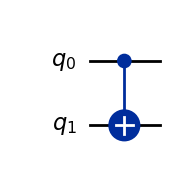


Truth Table for CNOT Gate:


,Input State,|00⟩,|01⟩,|10⟩,|11⟩
0,|00⟩,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,|01⟩,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j
2,|10⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j
3,|11⟩,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j


Bloch sphere of qubit 0 after CNOT on |+0⟩:


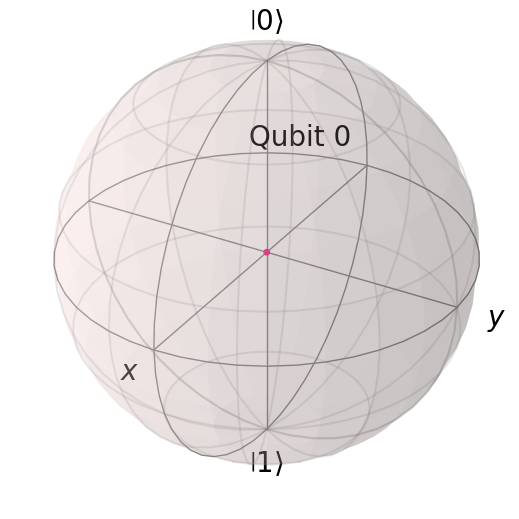

Bloch sphere of qubit 1 after CNOT on |+0⟩:


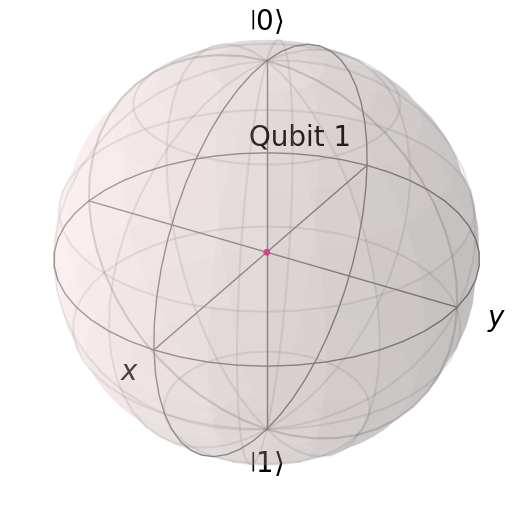

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, qubit=0, label="State"):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    # Partial trace to get reduced state of the qubit
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    bloch = Bloch()
    bloch.add_vectors(current_vector)
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

def visualize_cnot_gate():
    qc = QuantumCircuit(2)
    qc.cx(0, 1)
    display(qc.draw('mpl'))

    print("\nTruth Table for CNOT Gate:")
    input_states = [(0, 0), (0, 1), (1, 0), (1, 1)]
    rows = []

    for state_in in input_states:
        test_qc = QuantumCircuit(2)
        for i, bit in enumerate(state_in):
            if bit:
                test_qc.x(i)
        test_qc.cx(0, 1)

        state = Statevector.from_instruction(test_qc)
        amp_dict = {
            f"|{format(i, '02b')}⟩": amp
            for i, amp in enumerate(state.data)
        }

        row = [f"|{state_in[0]}{state_in[1]}⟩"] + [
            amp_dict.get(f"|{format(b, '02b')}⟩", 0) for b in range(4)
        ]
        rows.append(row)

    col_labels = ["Input State"] + [f"|{i:02b}⟩" for i in range(4)]
    df = pd.DataFrame(rows, columns=col_labels)
    display(df)

    # Show Bloch spheres for each qubit after applying CNOT on |+0⟩ state
    # Prepare initial state |+0⟩ = (H on qubit 0)
    qc_init = QuantumCircuit(2)
    qc_init.h(0)
    qc_init.cx(0,1)
    print("Bloch sphere of qubit 0 after CNOT on |+0⟩:")
    show_bloch_state(qc_init, qubit=0, label="Qubit 0")
    print("Bloch sphere of qubit 1 after CNOT on |+0⟩:")
    show_bloch_state(qc_init, qubit=1, label="Qubit 1")

# Run the function
visualize_cnot_gate()


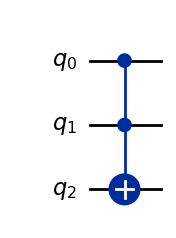


Truth Table for CCNOT (Toffoli) Gate:


,Input State,|000⟩,|001⟩,|010⟩,|011⟩,|100⟩,|101⟩,|110⟩,|111⟩
0,|000⟩,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,|001⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
2,|010⟩,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
3,|011⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j
4,|100⟩,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
5,|101⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j
6,|110⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j
7,|111⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j


Bloch sphere of qubit 0 after CCNOT on |++0⟩:


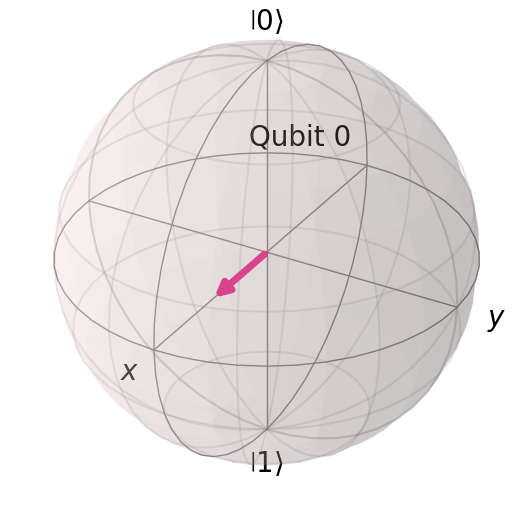

Bloch sphere of qubit 1 after CCNOT on |++0⟩:


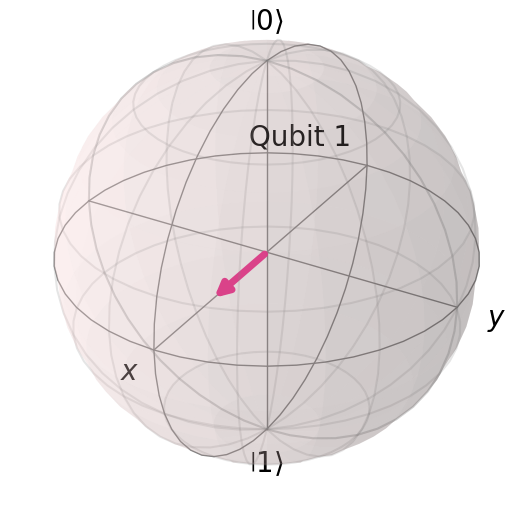

Bloch sphere of qubit 2 after CCNOT on |++0⟩:


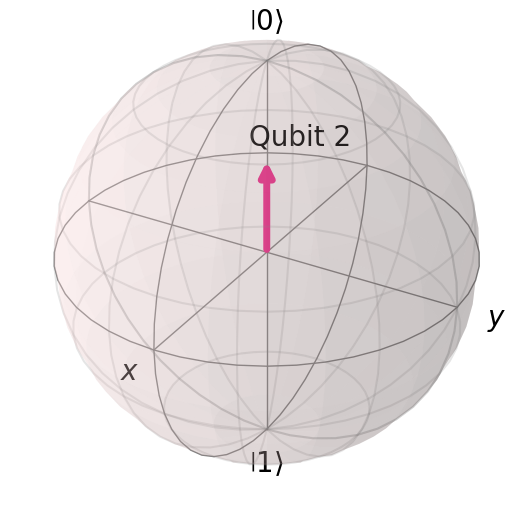

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, qubit=0, label="State"):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    bloch = Bloch()
    bloch.add_vectors(current_vector)
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

def visualize_ccnot_gate():
    qc = QuantumCircuit(3)
    qc.ccx(0, 1, 2)
    display(qc.draw('mpl'))

    print("\nTruth Table for CCNOT (Toffoli) Gate:")
    input_states = [(a, b, c) for a in [0, 1] for b in [0, 1] for c in [0, 1]]
    rows = []

    for state_in in input_states:
        test_qc = QuantumCircuit(3)
        for i, bit in enumerate(state_in):
            if bit:
                test_qc.x(i)
        test_qc.ccx(0, 1, 2)

        state = Statevector.from_instruction(test_qc)
        amp_dict = {
            f"|{format(i, '03b')}⟩": amp
            for i, amp in enumerate(state.data)
        }

        row = [f"|{state_in[0]}{state_in[1]}{state_in[2]}⟩"] + [
            amp_dict.get(f"|{format(b, '03b')}⟩", 0) for b in range(8)
        ]
        rows.append(row)

    col_labels = ["Input State"] + [f"|{i:03b}⟩" for i in range(8)]
    df = pd.DataFrame(rows, columns=col_labels)
    display(df)

    # Prepare initial state |++0⟩ = H on qubits 0 and 1, qubit 2 in |0>
    qc_init = QuantumCircuit(3)
    qc_init.h(0)
    qc_init.h(1)
    qc_init.ccx(0, 1, 2)

    for qubit in range(3):
        print(f"Bloch sphere of qubit {qubit} after CCNOT on |++0⟩:")
        show_bloch_state(qc_init, qubit=qubit, label=f"Qubit {qubit}")

# Run the function
visualize_ccnot_gate()


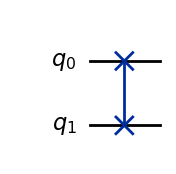


Truth Table for SWAP Gate:


,Input State,|00⟩,|01⟩,|10⟩,|11⟩
0,|00⟩,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,|01⟩,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j
2,|10⟩,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j
3,|11⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j


Bloch sphere of qubit 0 after SWAP on |+0⟩:


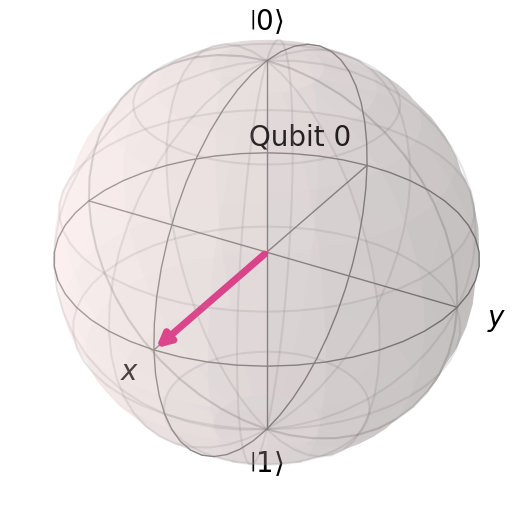

Bloch sphere of qubit 1 after SWAP on |+0⟩:


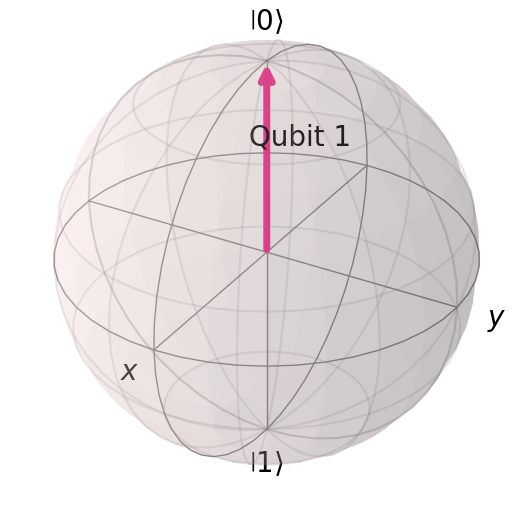

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, qubit=0, label="State"):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    bloch = Bloch()
    bloch.add_vectors(current_vector)
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

def visualize_swap_gate():
    qc = QuantumCircuit(2)
    qc.swap(0, 1)
    display(qc.draw('mpl'))

    print("\nTruth Table for SWAP Gate:")
    input_states = [(0, 0), (0, 1), (1, 0), (1, 1)]
    rows = []

    for state_in in input_states:
        test_qc = QuantumCircuit(2)
        for i, bit in enumerate(state_in):
            if bit:
                test_qc.x(i)
        test_qc.swap(0, 1)

        state = Statevector.from_instruction(test_qc)
        amp_dict = {
            f"|{format(i, '02b')}⟩": amp
            for i, amp in enumerate(state.data)
        }

        row = [f"|{state_in[0]}{state_in[1]}⟩"] + [
            amp_dict.get(f"|{format(b, '02b')}⟩", 0) for b in range(4)
        ]
        rows.append(row)

    col_labels = ["Input State"] + [f"|{i:02b}⟩" for i in range(4)]
    df = pd.DataFrame(rows, columns=col_labels)
    display(df)

    # Show Bloch spheres for each qubit after applying SWAP on |+0⟩ state
    qc_init = QuantumCircuit(2)
    qc_init.h(0)
    qc_init.swap(0, 1)
    print("Bloch sphere of qubit 0 after SWAP on |+0⟩:")
    show_bloch_state(qc_init, qubit=0, label="Qubit 0")
    print("Bloch sphere of qubit 1 after SWAP on |+0⟩:")
    show_bloch_state(qc_init, qubit=1, label="Qubit 1")

# Run the function
visualize_swap_gate()


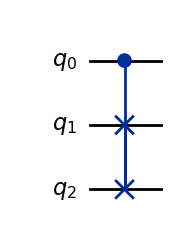


Truth Table for Controlled SWAP (Fredkin) Gate:


,Input State,|000⟩,|001⟩,|010⟩,|011⟩,|100⟩,|101⟩,|110⟩,|111⟩
0,|000⟩,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,|001⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
2,|010⟩,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
3,|011⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j
4,|100⟩,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
5,|101⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
6,|110⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j,0.0+0.0j,0.0+0.0j
7,|111⟩,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j,1.0+0.0j


Bloch sphere of qubit 0 after Controlled SWAP on |++0⟩:


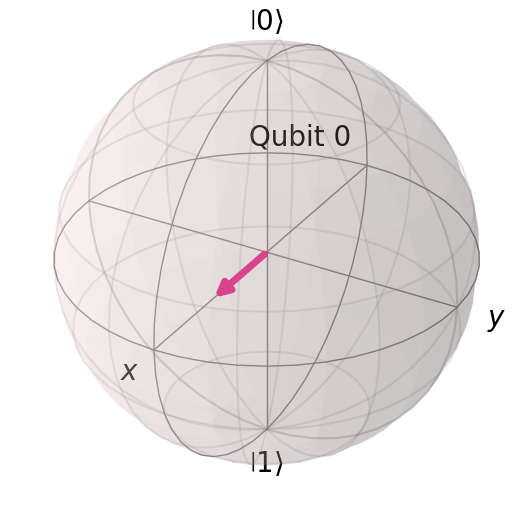

Bloch sphere of qubit 1 after Controlled SWAP on |++0⟩:


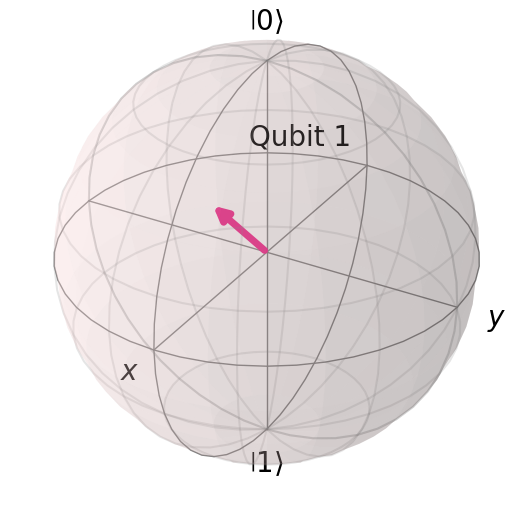

Bloch sphere of qubit 2 after Controlled SWAP on |++0⟩:


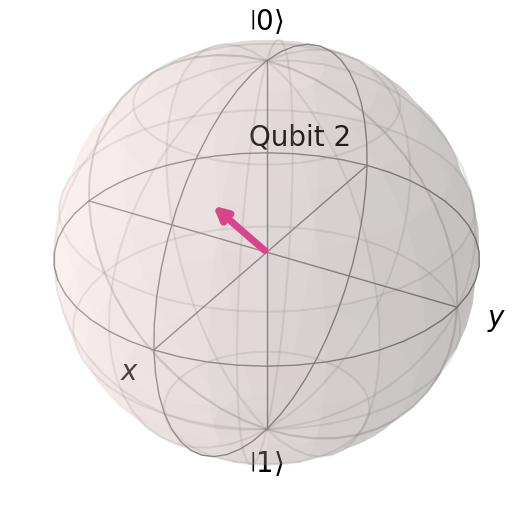

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, Pauli, partial_trace
from qiskit.visualization.bloch import Bloch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

simulator = AerSimulator()

def show_bloch_state(circuit, qubit=0, label="State"):
    temp_circuit = circuit.copy()
    temp_circuit.save_statevector()
    compiled = transpile(temp_circuit, simulator)
    result = simulator.run(compiled).result()
    statevector = result.get_statevector()

    rho = DensityMatrix(statevector)
    reduced_rho = partial_trace(rho, [i for i in range(circuit.num_qubits) if i != qubit])

    current_vector = [
        np.real(reduced_rho.expectation_value(Pauli("X"))),
        np.real(reduced_rho.expectation_value(Pauli("Y"))),
        np.real(reduced_rho.expectation_value(Pauli("Z")))
    ]

    bloch = Bloch()
    bloch.add_vectors(current_vector)
    bloch.add_annotation([0.4, 0.4, 0.9], label)
    bloch.show()

def visualize_controlled_swap_gate():
    qc = QuantumCircuit(3)
    qc.cswap(0, 1, 2)  # Controlled SWAP (Fredkin) gate with qubit 0 as control
    display(qc.draw('mpl'))

    print("\nTruth Table for Controlled SWAP (Fredkin) Gate:")
    input_states = [(a, b, c) for a in [0,1] for b in [0,1] for c in [0,1]]
    rows = []

    for state_in in input_states:
        test_qc = QuantumCircuit(3)
        for i, bit in enumerate(state_in):
            if bit:
                test_qc.x(i)
        test_qc.cswap(0, 1, 2)

        state = Statevector.from_instruction(test_qc)
        amp_dict = {
            f"|{format(i, '03b')}⟩": amp
            for i, amp in enumerate(state.data)
        }

        row = [f"|{state_in[0]}{state_in[1]}{state_in[2]}⟩"] + [
            amp_dict.get(f"|{format(b, '03b')}⟩", 0) for b in range(8)
        ]
        rows.append(row)

    col_labels = ["Input State"] + [f"|{i:03b}⟩" for i in range(8)]
    df = pd.DataFrame(rows, columns=col_labels)
    display(df)

    # Prepare initial state |++0⟩ = H on qubits 0 and 1, qubit 2 in |0⟩
    qc_init = QuantumCircuit(3)
    qc_init.h(0)
    qc_init.h(1)
    qc_init.cswap(0, 1, 2)

    for qubit in range(3):
        print(f"Bloch sphere of qubit {qubit} after Controlled SWAP on |++0⟩:")
        show_bloch_state(qc_init, qubit=qubit, label=f"Qubit {qubit}")

# Run the function
visualize_controlled_swap_gate()
